**Import Library**

In [23]:
import numpy as np
import matplotlib.pyplot as plt

**Pembuatan Rentang Berat**

In [24]:
# Range berat (gram)
x = np.linspace(0, 1000, 1000)

**Fungsi Membership**

In [25]:
# Fungsi Membership - Segitiga
"""
    Fungsi Membership Segitiga (Triangular Membership Function)

    Parameter:
    x : nilai input (misalnya berat dalam gram)
    a : titik awal (derajat keanggotaan = 0)
    b : titik puncak (derajat keanggotaan = 1)
    c : titik akhir (derajat keanggotaan = 0)

    Bentuk grafik:
          ^
         / \
        /   \
       /     \
      a   b   c

    Penjelasan:
    - Dari a ke b → nilai naik secara linear (0 → 1)
    - Dari b ke c → nilai turun secara linear (1 → 0)
    - Di luar [a, c] → keanggotaan = 0

    Output:
    Nilai derajat keanggotaan antara 0 dan 1
"""

def triangular(x, a, b, c):
    # Ensure x is an array for consistent numpy operations
    is_scalar = not isinstance(x, np.ndarray)
    if is_scalar:
        x = np.array([x])

    res = np.zeros_like(x, dtype=float)

    # Case: a = b = c (singleton at a)
    if a == b and b == c:
        res[x == a] = 1.0
        return res[0] if is_scalar else res

    # Handle the increasing part: a < x <= b
    if b > a:
        mask = (x > a) & (x <= b)
        res[mask] = (x[mask] - a) / (b - a)
    elif a == b: # If a == b, membership is 1 at x = a and to its left (for the "light" case)
        mask = (x <= a)
        res[mask] = 1.0

    # Handle the decreasing part: b < x < c
    if c > b:
        mask = (x > b) & (x < c)
        res[mask] = (c - x[mask]) / (c - b)
    elif b == c: # If b == c, membership is 1 at x = b and to its right (for the "heavy" case)
        mask = (x >= b)
        res[mask] = 1.0

    # Clamp the results to [0, 1] to handle potential floating point inaccuracies or edge case calculations.
    res = np.clip(res, 0.0, 1.0)

    return res[0] if is_scalar else res

**Kelas Membership**

In [26]:
# Ringan
light = triangular(x, 0, 0, 400)

# Sedang
medium = triangular(x, 200, 500, 800)

# Berat
heavy = triangular(x, 600, 1000, 1000)

**Plot Grafik Membership**

**Uji Data**

In [36]:
import pandas as pd

# Generate 10 sample weight data points sequentially
berat_data = [100, 225, 335, 480] # Added 480 to include a medium weight example

# Initialize lists to store membership values
mu_light_list = []
mu_medium_list = []
mu_heavy_list = []

# Calculate membership for each weight
for berat_val in berat_data:
    mu_light = triangular(berat_val, 0, 0, 400)
    mu_medium = triangular(berat_val, 200, 500, 800)
    mu_heavy = triangular(berat_val, 600, 1000, 1000)

    mu_light_list.append(mu_light)
    mu_medium_list.append(mu_medium)
    mu_heavy_list.append(mu_heavy)

# Create a DataFrame to display the results
df = pd.DataFrame({
    'Berat (gram)': berat_data,
    'Ringan': mu_light_list,
    'Sedang': mu_medium_list,
    'Berat': mu_heavy_list
})

# Determine the dominant category
def get_dominant_category(row):
    memberships = {'Ringan': row['Ringan'], 'Sedang': row['Sedang'], 'Berat': row['Berat']}
    # Find the maximum membership value
    max_mu = max(memberships.values())

    # If all memberships are zero, return 'Tidak Ada' or 'N/A'
    if max_mu == 0:
        return 'Tidak Ada Kategori Dominan'

    # Find all categories with the maximum membership value
    dominant_categories = [cat for cat, mu in memberships.items() if mu == max_mu]

    # If there's more than one dominant category (a tie), you can customize how to display it
    # For simplicity, we'll return the first one, or join them if multiple.
    if len(dominant_categories) == 1:
        return dominant_categories[0]
    else:
        return f"{'/'.join(dominant_categories)} (Tie)"

df['Kategori Dominan'] = df.apply(get_dominant_category, axis=1)

# Format membership columns to two decimal places for display
df['Ringan'] = df['Ringan'].apply(lambda x: f'{x:.2f}')
df['Sedang'] = df['Sedang'].apply(lambda x: f'{x:.2f}')
df['Berat'] = df['Berat'].apply(lambda x: f'{x:.2f}')

print("Tabel Nilai Keanggotaan dan Kategori Dominan:")
print(df)

Tabel Nilai Keanggotaan dan Kategori Dominan:
   Berat (gram) Ringan Sedang Berat Kategori Dominan
0           100   0.75   0.00  0.00           Ringan
1           225   0.44   0.08  0.00           Ringan
2           335   0.16   0.45  0.00           Sedang
3           480   0.00   0.93  0.00           Sedang


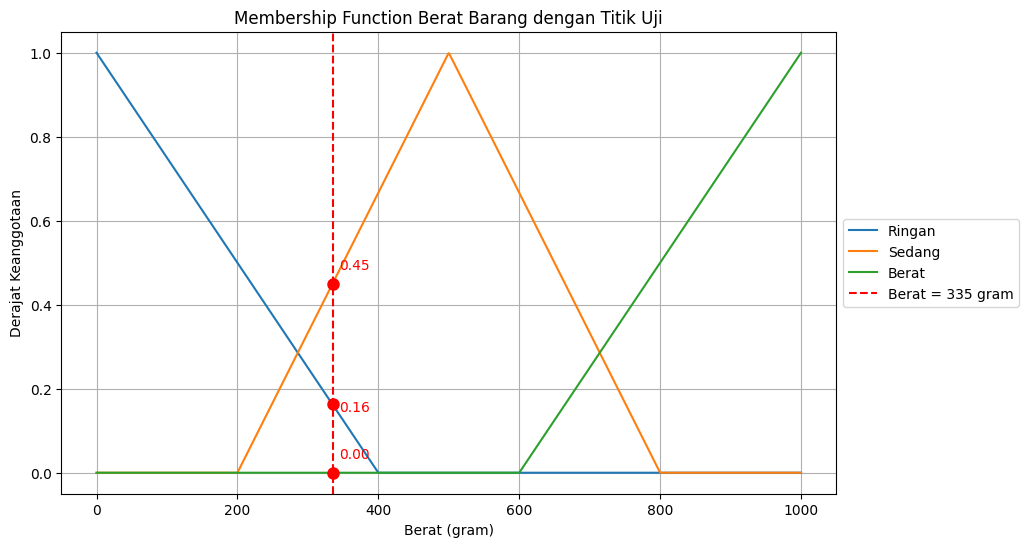

In [44]:
plt.figure(figsize=(10, 6))

plt.plot(x, light, label="Ringan")
plt.plot(x, medium, label="Sedang")
plt.plot(x, heavy, label="Berat")

# Specific weight to visualize
berat_to_plot = 335

# Calculate membership values for the specific weight
mu_light_at_100 = triangular(berat_to_plot, 0, 0, 400)
mu_medium_at_100 = triangular(berat_to_plot, 200, 500, 800)
mu_heavy_at_100 = triangular(berat_to_plot, 600, 1000, 1000)

# Plot a vertical line at the specific weight
plt.axvline(x=berat_to_plot, color='r', linestyle='--', label=f'Berat = {berat_to_plot} gram')

# Plot points for membership values
plt.plot(berat_to_plot, mu_light_at_100, 'ro', markersize=8)
plt.annotate(f'{mu_light_at_100:.2f}', (berat_to_plot, mu_light_at_100), textcoords="offset points", xytext=(5,-5), ha='left', color='red')

plt.plot(berat_to_plot, mu_medium_at_100, 'ro', markersize=8)
plt.annotate(f'{mu_medium_at_100:.2f}', (berat_to_plot, mu_medium_at_100), textcoords="offset points", xytext=(5,10), ha='left', color='red')

plt.plot(berat_to_plot, mu_heavy_at_100, 'ro', markersize=8)
plt.annotate(f'{mu_heavy_at_100:.2f}', (berat_to_plot, mu_heavy_at_100), textcoords="offset points", xytext=(5,10), ha='left', color='red')


plt.title("Membership Function Berat Barang dengan Titik Uji")
plt.xlabel("Berat (gram)")
plt.ylabel("Derajat Keanggotaan")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True)

plt.show()